# f6_m01a_shap_global.ipynb
**TFM: Pronóstico del Éxito y del Abandono en los Títulos de Grado de la UJI**

| | |
|---|---|
| **Autora** | María José Morte Ruiz |
| **Institución** | UOC + Universitat Jaume I |
| **Email** | mjmorteruiz@uoc.edu · morte@uji.es |
| **Fase** | 6 — Interpretabilidad y Evaluación Final |
| **Módulo** | M01a — SHAP Global |

---

## 🎯 Qué hace

Calcula e interpreta la importancia global de features con SHAP sobre el conjunto de test.
Genera gráficos beeswarm, bar plot, heatmap y **dependence plots** para CatBoost, EBM y RF.
Los dependence plots revelan umbrales críticos de riesgo — nivel paper de investigación.

## 📋 Requisitos

- `data/05_modelado/X_test_prep.parquet` — 6.725 obs × 27 features
- `data/05_modelado/y_test.parquet`
- `data/05_modelado/models/CatBoost__balanced.pkl`
- `data/05_modelado/models/EBM__balanced.pkl`
- `data/05_modelado/models/RandomForest__balanced.pkl`
- `src/config_entorno.py` — NOMBRES_LEGIBLES_FEATURES

## 📤 Genera

| Archivo | Contenido |
|---|---|
| `results/fase6/shap_global_catboost.pkl` | SHAP values CatBoost (cache validado) |
| `results/fase6/shap_global_catboost_meta.json` | Metadatos validación |
| `results/fase6/shap_global_rf.pkl` | SHAP values RF (cache validado) |
| `results/fase6/shap_global_rf_meta.json` | Metadatos validación |
| `results/fase6/ebm_importancia_global.parquet` | Importancias EBM |
| `results/fase6/shap_importancia_comparativa.parquet` | Rankings unificados |
| `results/fase6/shap_beeswarm_catboost.png` | Beeswarm |
| `results/fase6/shap_bar_comparativo.png` | Bar plot 3 modelos |
| `results/fase6/shap_heatmap_catboost.png` | Heatmap |
| `results/fase6/shap_dependence_top3.png` | **Dependence plots top 3 features** |
| `docs/html/fase6/m01a_shap_global.html` | Informe HTML |

## 🔄 Flujo

```
X_test_prep + modelos pkl
    ↓ Cache validado SHAP CatBoost + RF
    ↓ EBM importancias nativas
    ↓ Tabla comparativa rankings 3 modelos
    ↓ Beeswarm → Bar → Heatmap → Dependence plots (nuevo)
    → results/fase6/ + m01a_shap_global.html
```

## ➡️ Siguiente

`f6_m01b_shap_local.ipynb`


In [1]:
# ============================================================
# CELDA 1: CONFIGURACIÓN DE RUTAS
# ============================================================
import sys
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

def _encontrar_root(start: Path) -> Path:
    for parent in [start] + list(start.parents):
        if (parent / 'src').is_dir():
            return parent
    raise FileNotFoundError('No se encontró src/ subiendo desde ' + str(start))

ROOT = _encontrar_root(Path.cwd())
sys.path.insert(0, str(ROOT))

DIR_DATA    = ROOT / 'data' / '05_modelado'
DIR_MODELS  = ROOT / 'data' / '05_modelado' / 'models'
DIR_RESULTS = ROOT / 'results' / 'fase6'
DIR_HTML    = ROOT / 'docs' / 'html' / 'fase6'
DIR_RESULTS.mkdir(parents=True, exist_ok=True)
DIR_HTML.mkdir(parents=True, exist_ok=True)

print(f'ROOT:       {ROOT}')
print(f'DIR_MODELS: {DIR_MODELS}')
print(f'DIR_RESULTS:{DIR_RESULTS}')

ROOT:       C:\Users\mjmor\OneDrive - Universitat Jaume I\2.- AU_UJI
DIR_MODELS: C:\Users\mjmor\OneDrive - Universitat Jaume I\2.- AU_UJI\data\05_modelado\models
DIR_RESULTS:C:\Users\mjmor\OneDrive - Universitat Jaume I\2.- AU_UJI\results\fase6


In [2]:
# ============================================================
# CELDA 2: IMPORTS
# NOMBRES_LEGIBLES_FEATURES desde config_entorno — fuente
# única de verdad, no hardcodeado en el notebook.
# ============================================================
import json
import hashlib
import base64
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import joblib
import shap
from src.html.render import render_pagina_desde_fichero
from src.utils.progress import spinner
from src.config_entorno import NOMBRES_LEGIBLES_FEATURES

matplotlib.rcParams['figure.dpi'] = 120
shap.initjs()

# Función helper para nombres legibles sin guiones bajos
def nombre_legible(f: str) -> str:
    return NOMBRES_LEGIBLES_FEATURES.get(f, f.replace('_', ' '))

print('Imports OK.')

Imports OK.


In [3]:
# ============================================================
# CELDA 3: CARGAR DATOS
# X_test_prep: 27 features (24 + 3 _missing) — ya preprocesadas
# ============================================================
X_test = pd.read_parquet(DIR_DATA / 'X_test_prep.parquet')
y_test = pd.read_parquet(DIR_DATA / 'y_test.parquet').squeeze()

feature_names = X_test.columns.tolist()

print(f'X_test:   {X_test.shape}')
print(f'y_test:   {y_test.shape}')
print(f'Features ({len(feature_names)}): {feature_names}')

X_test:   (6725, 27)
y_test:   (6725,)
Features (27): ['cred_superados_anio_1er', 'cupo', 'pais_nombre', 'provincia', 'universidad_origen', 'edad_entrada', 'anios_gap', 'nota_1er_anio', 'nota_acceso', 'nota_selectividad', 'via_acceso', 'rama', 'n_anios_beca', 'anios_sin_beca', 'situacion_laboral', 'n_anios_trabajando', 'max_pagos', 'orden_preferencia', 'cred_repetidos', 'tasa_repeticion', 'n_anios_sin_notas', 'tasa_abandono_titulacion', 'sexo', 'indicador_interrupcion', 'nota_1er_anio_missing', 'nota_acceso_missing', 'nota_selectividad_missing']


In [4]:
# ============================================================
# CELDA 4: CARGAR MODELOS
# ============================================================
def cargar_modelo(nombre: str):
    ruta = DIR_MODELS / nombre
    if not ruta.exists():
        raise FileNotFoundError(f'Modelo no encontrado: {ruta}')
    print(f'  Cargando: {nombre}')
    return joblib.load(ruta)

print('Cargando modelos...')
modelo_catboost = cargar_modelo('CatBoost__balanced.pkl')
modelo_ebm      = cargar_modelo('EBM__balanced.pkl')
modelo_rf       = cargar_modelo('RandomForest__balanced.pkl')
print('Modelos cargados.')

Cargando modelos...
  Cargando: CatBoost__balanced.pkl
  Cargando: EBM__balanced.pkl
  Cargando: RandomForest__balanced.pkl
Modelos cargados.


In [5]:
# ============================================================
# CELDA 5: CACHE VALIDADO — FUNCIONES
# Patrón profesional: guardar cálculos pesados en disco
# validando shape + hash antes de reutilizar.
# ============================================================
def _hash_df(df: pd.DataFrame, n: int = 500) -> str:
    muestra = df.iloc[:n].values.tobytes()
    return hashlib.md5(muestra).hexdigest()[:12]

def _meta_esperado(df: pd.DataFrame) -> dict:
    return {'n_obs': int(len(df)), 'n_features': int(df.shape[1]), 'hash_xtest': _hash_df(df)}

def _cache_valido(ruta_pkl: Path, ruta_meta: Path, meta_esp: dict) -> bool:
    if not ruta_pkl.exists() or not ruta_meta.exists():
        return False
    meta_guardado = json.loads(ruta_meta.read_text())
    if meta_guardado != meta_esp:
        print(f'  ⚠️  Cache desactualizado: {meta_guardado} vs {meta_esp}')
        return False
    return True

def _limpiar_cache(ruta_pkl: Path, ruta_meta: Path):
    for r in [ruta_pkl, ruta_meta]:
        if r.exists():
            r.unlink()
            print(f'  🗑️  Eliminado: {r.name}')

def _guardar_cache(obj, ruta_pkl: Path, ruta_meta: Path, meta: dict):
    joblib.dump(obj, ruta_pkl)
    ruta_meta.write_text(json.dumps(meta))
    print(f'  💾 Guardado: {ruta_pkl.name} + metadatos')

META_XTEST = _meta_esperado(X_test)
print(f'Metadatos X_test: {META_XTEST}')

Metadatos X_test: {'n_obs': 6725, 'n_features': 27, 'hash_xtest': '341d02375a7b'}


In [6]:
# ============================================================
# CELDA 6: CALCULAR SHAP — CATBOOST
# ============================================================
RUTA_SHAP_CAT = DIR_RESULTS / 'shap_global_catboost.pkl'
RUTA_META_CAT = DIR_RESULTS / 'shap_global_catboost_meta.json'

if _cache_valido(RUTA_SHAP_CAT, RUTA_META_CAT, META_XTEST):
    print('✅ Cargando SHAP CatBoost desde caché validado...')
    shap_cat = joblib.load(RUTA_SHAP_CAT)
else:
    _limpiar_cache(RUTA_SHAP_CAT, RUTA_META_CAT)
    catboost_raw = modelo_catboost.named_steps['model']
    with spinner('⏳ Calculando SHAP CatBoost...'):
        explainer_cat = shap.TreeExplainer(catboost_raw)
        shap_cat      = explainer_cat(X_test)
    _guardar_cache(shap_cat, RUTA_SHAP_CAT, RUTA_META_CAT, META_XTEST)

print(f'\nshap_cat shape: {shap_cat.values.shape}')
assert shap_cat.values.shape[1] == len(feature_names)

✅ Cargando SHAP CatBoost desde caché validado...

shap_cat shape: (6725, 27)


In [7]:
# ============================================================
# CELDA 7: CALCULAR SHAP — RANDOM FOREST
# RF tarda más que CatBoost (~5-15 min en CPU).
# ============================================================
RUTA_SHAP_RF = DIR_RESULTS / 'shap_global_rf.pkl'
RUTA_META_RF = DIR_RESULTS / 'shap_global_rf_meta.json'

if _cache_valido(RUTA_SHAP_RF, RUTA_META_RF, META_XTEST):
    print('✅ Cargando SHAP RF desde caché validado...')
    shap_rf = joblib.load(RUTA_SHAP_RF)
else:
    _limpiar_cache(RUTA_SHAP_RF, RUTA_META_RF)
    rf_raw = modelo_rf.named_steps['model']
    with spinner('⏳ Calculando SHAP RF (5-15 min)...'):
        explainer_rf = shap.TreeExplainer(rf_raw)
        shap_rf      = explainer_rf(X_test)
    _guardar_cache(shap_rf, RUTA_SHAP_RF, RUTA_META_RF, META_XTEST)

print(f'\nshap_rf shape: {shap_rf.values.shape}')
assert shap_rf.values.shape[1] == len(feature_names)

✅ Cargando SHAP RF desde caché validado...

shap_rf shape: (6725, 27, 2)


In [8]:
# ============================================================
# CELDA 8: IMPORTANCIAS EBM — MÉTODO NATIVO
# ============================================================
RUTA_EBM_IMP  = DIR_RESULTS / 'ebm_importancia_global.parquet'
RUTA_EBM_META = DIR_RESULTS / 'ebm_importancia_global_meta.json'
meta_ebm_esp  = {'n_features': len(feature_names)}

if RUTA_EBM_IMP.exists() and RUTA_EBM_META.exists():
    if json.loads(RUTA_EBM_META.read_text()) == meta_ebm_esp:
        print('✅ Cargando EBM desde caché...')
        df_ebm_imp = pd.read_parquet(RUTA_EBM_IMP)
    else:
        RUTA_EBM_IMP.unlink(); RUTA_EBM_META.unlink()
        df_ebm_imp = None
else:
    df_ebm_imp = None

if df_ebm_imp is None:
    ebm_raw = modelo_ebm.named_steps['model']
    with spinner('⏳ Calculando EBM...'):
        datos_ebm = ebm_raw.explain_global().data()
        df_ebm_imp = pd.DataFrame({
            'feature': datos_ebm['names'], 'importancia': datos_ebm['scores']
        }).set_index('feature').sort_values('importancia', ascending=False)
    df_ebm_imp.to_parquet(RUTA_EBM_IMP)
    RUTA_EBM_META.write_text(json.dumps(meta_ebm_esp))
    print('  💾 EBM guardado.')

print(f'Top 5 EBM: {df_ebm_imp.head().index.tolist()}')

✅ Cargando EBM desde caché...
Top 5 EBM: ['n_anios_beca', 'anios_sin_beca', 'cred_superados_anio_1er & n_anios_trabajando', 'cred_superados_anio_1er', 'n_anios_beca & n_anios_trabajando']


In [9]:
# ============================================================
# CELDA 9: IMPORTANCIAS SHAP — FUNCIÓN Y TABLA COMPARATIVA
# ============================================================
def importancia_shap(shap_values, nombres: list) -> pd.Series:
    vals = shap_values.values if hasattr(shap_values, 'values') else shap_values
    if vals.ndim == 3:
        vals = vals[:, :, 1]
    assert vals.shape[1] == len(nombres)
    return pd.Series(np.abs(vals).mean(axis=0), index=nombres).sort_values(ascending=False)

imp_cat = importancia_shap(shap_cat, feature_names)
imp_rf  = importancia_shap(shap_rf,  feature_names)
imp_ebm = df_ebm_imp['importancia'].reindex(feature_names).fillna(0)

df_imp = pd.DataFrame({'CatBoost': imp_cat, 'RF': imp_rf, 'EBM': imp_ebm}).fillna(0)
df_imp['rank_cat']   = df_imp['CatBoost'].rank(ascending=False).astype(int)
df_imp['rank_rf']    = df_imp['RF'].rank(ascending=False).astype(int)
df_imp['rank_ebm']   = df_imp['EBM'].rank(ascending=False).astype(int)
df_imp['rank_medio'] = (df_imp['rank_cat'] + df_imp['rank_rf'] + df_imp['rank_ebm']) / 3
df_imp['discrepancia'] = (
    df_imp[['rank_cat','rank_rf','rank_ebm']].max(axis=1) -
    df_imp[['rank_cat','rank_rf','rank_ebm']].min(axis=1)
)

df_imp.to_parquet(DIR_RESULTS / 'shap_importancia_comparativa.parquet')
print('Top 10 por consenso:')
print(df_imp.nsmallest(10, 'rank_medio')[['CatBoost','RF','EBM','rank_cat','rank_rf','rank_ebm']].to_string())

Top 10 por consenso:
                         CatBoost        RF       EBM  rank_cat  rank_rf  rank_ebm
cred_superados_anio_1er  0.603551  0.084432  0.543833         3        1         3
n_anios_beca             0.608261  0.054327  1.097888         2        5         1
n_anios_trabajando       0.686371  0.077127  0.488003         1        2         5
n_anios_sin_notas        0.455573  0.037908  0.511198         4        7         4
nota_1er_anio            0.423307  0.051557  0.407334         5        6         6
cred_repetidos           0.357366  0.065344  0.301256         7        3         9
anios_sin_beca           0.351102  0.018104  0.912837         8       11         2
situacion_laboral        0.373180  0.033127  0.406429         6        8         7
tasa_repeticion          0.271718  0.063299  0.246315         9        4        10
nota_acceso              0.230796  0.029717  0.307879        10        9         8


In [ ]:
# ============================================================
# CELDA 9b: BOOTSTRAP CONFIDENCE INTERVALS — IMPORTANCIAS SHAP 🏆
# En lugar de un punto de importancia, calculamos un intervalo
# de confianza al 95% mediante bootstrap (1000 remuestras).
# Muestra qué features tienen importancia ROBUSTA vs cuáles son
# sensibles a la muestra — nivel paper de investigación.
# Solo para CatBoost (más rápido que RF para 1000 iteraciones).
# ============================================================
N_BOOTSTRAP = 200   # 200 iteraciones — equilibrio velocidad/precisión
N_MUESTRA   = 500   # muestra por iteración (de los 6725 de test)
TOP_N       = 10    # solo top 10 features

rng_boot = np.random.default_rng(42)
shap_vals_arr = shap_cat.values
if shap_vals_arr.ndim == 3:
    shap_vals_arr = shap_vals_arr[:, :, 1]

top10_features = df_imp.nsmallest(TOP_N, 'rank_medio').index.tolist()
top10_idx = [feature_names.index(f) for f in top10_features]

print(f'Bootstrap {N_BOOTSTRAP} iteraciones × {N_MUESTRA} obs...')
boot_imps = np.zeros((N_BOOTSTRAP, TOP_N))

for b in range(N_BOOTSTRAP):
    idx = rng_boot.choice(len(shap_vals_arr), size=N_MUESTRA, replace=True)
    boot_imps[b] = np.abs(shap_vals_arr[idx][:, top10_idx]).mean(axis=0)

# IC 95%
ic_lo = np.percentile(boot_imps, 2.5, axis=0)
ic_hi = np.percentile(boot_imps, 97.5, axis=0)
ic_me = np.percentile(boot_imps, 50,   axis=0)

df_boot = pd.DataFrame({
    'feature':  top10_features,
    'median':   ic_me,
    'ic_lo':    ic_lo,
    'ic_hi':    ic_hi,
    'ic_width': ic_hi - ic_lo,
}).set_index('feature')

print('\nTop 10 features con IC 95% bootstrap:')
print(df_boot.round(4).to_string())

# Gráfico de puntos con barras de error
labels = [nombre_legible(f) for f in top10_features]
x = np.arange(len(top10_features))

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x, ic_me, color='#3182ce', alpha=0.7, label='Mediana bootstrap')
ax.errorbar(x, ic_me, 
            yerr=[ic_me - ic_lo, ic_hi - ic_me],
            fmt='none', color='#2d3748', capsize=5, linewidth=1.5,
            label='IC 95% bootstrap')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=35, ha='right', fontsize=9)
ax.set_ylabel('Mean |SHAP| (mediana bootstrap)', fontsize=10)
ax.set_title(
    'Fase 6 — Importancias SHAP con Bootstrap Confidence Intervals (IC 95%)\n'    f'CatBoost · {N_BOOTSTRAP} iteraciones · {N_MUESTRA} obs/iteración',
    fontsize=12
)
ax.legend(fontsize=9)
plt.tight_layout()
ruta_boot = DIR_RESULTS / 'shap_bootstrap_ic.png'
plt.savefig(ruta_boot, dpi=120, bbox_inches='tight')
plt.close()
print(f'\n✅ Bootstrap IC guardado: {ruta_boot.name}')

# Feature más estable (IC más estrecho relativo)
df_boot['cv_ic'] = df_boot['ic_width'] / df_boot['median']
mas_estable = df_boot['cv_ic'].idxmin()
mas_inestable = df_boot['cv_ic'].idxmax()
print(f'Feature más estable:   {nombre_legible(mas_estable)} (CV_IC={df_boot.loc[mas_estable,"cv_ic"]:.3f})')
print(f'Feature más inestable: {nombre_legible(mas_inestable)} (CV_IC={df_boot.loc[mas_inestable,"cv_ic"]:.3f})')


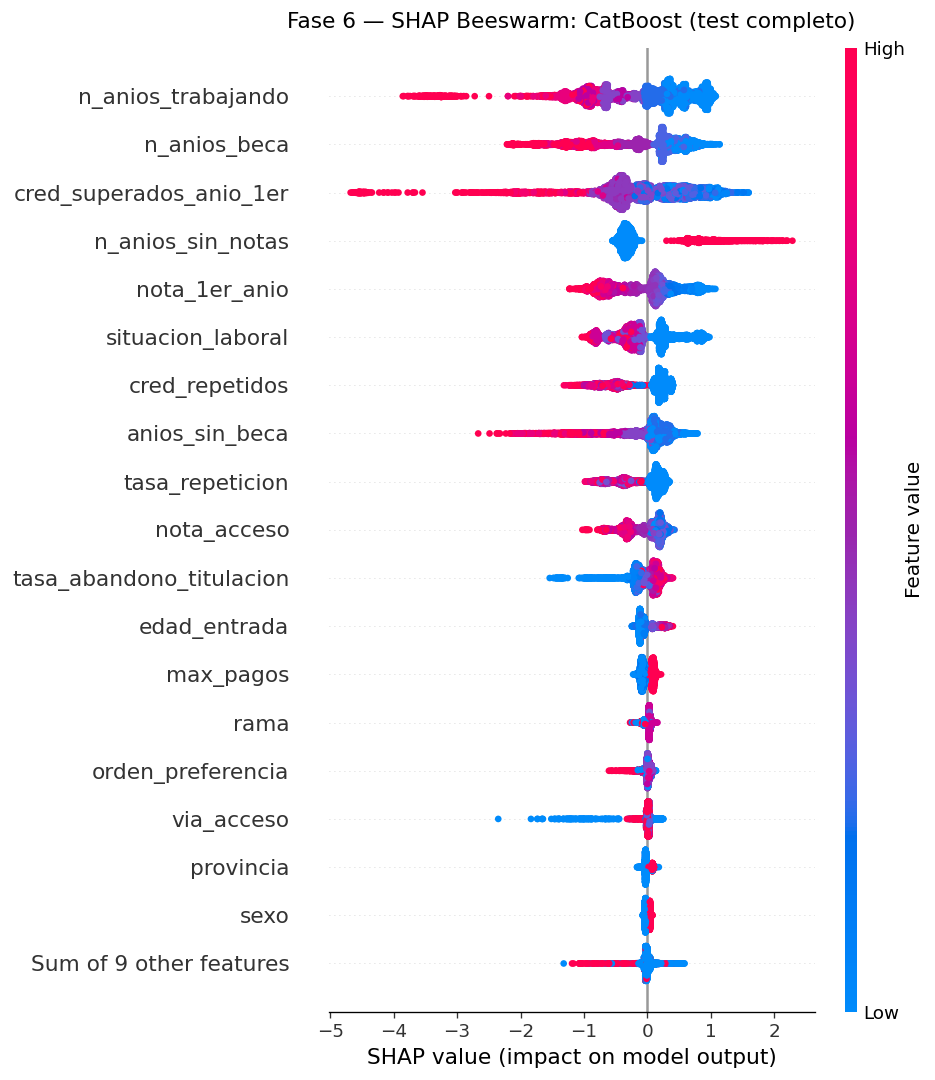

✅ Beeswarm guardado.


In [10]:
# ============================================================
# CELDA 10: GRÁFICO 1 — BEESWARM CATBOOST
# ============================================================
fig, ax = plt.subplots(figsize=(10, 7))
shap.plots.beeswarm(shap_cat, max_display=19, show=False)
plt.title('Fase 6 — SHAP Beeswarm: CatBoost (test completo)', fontsize=13, pad=12)
plt.tight_layout()
plt.savefig(DIR_RESULTS / 'shap_beeswarm_catboost.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Beeswarm guardado.')

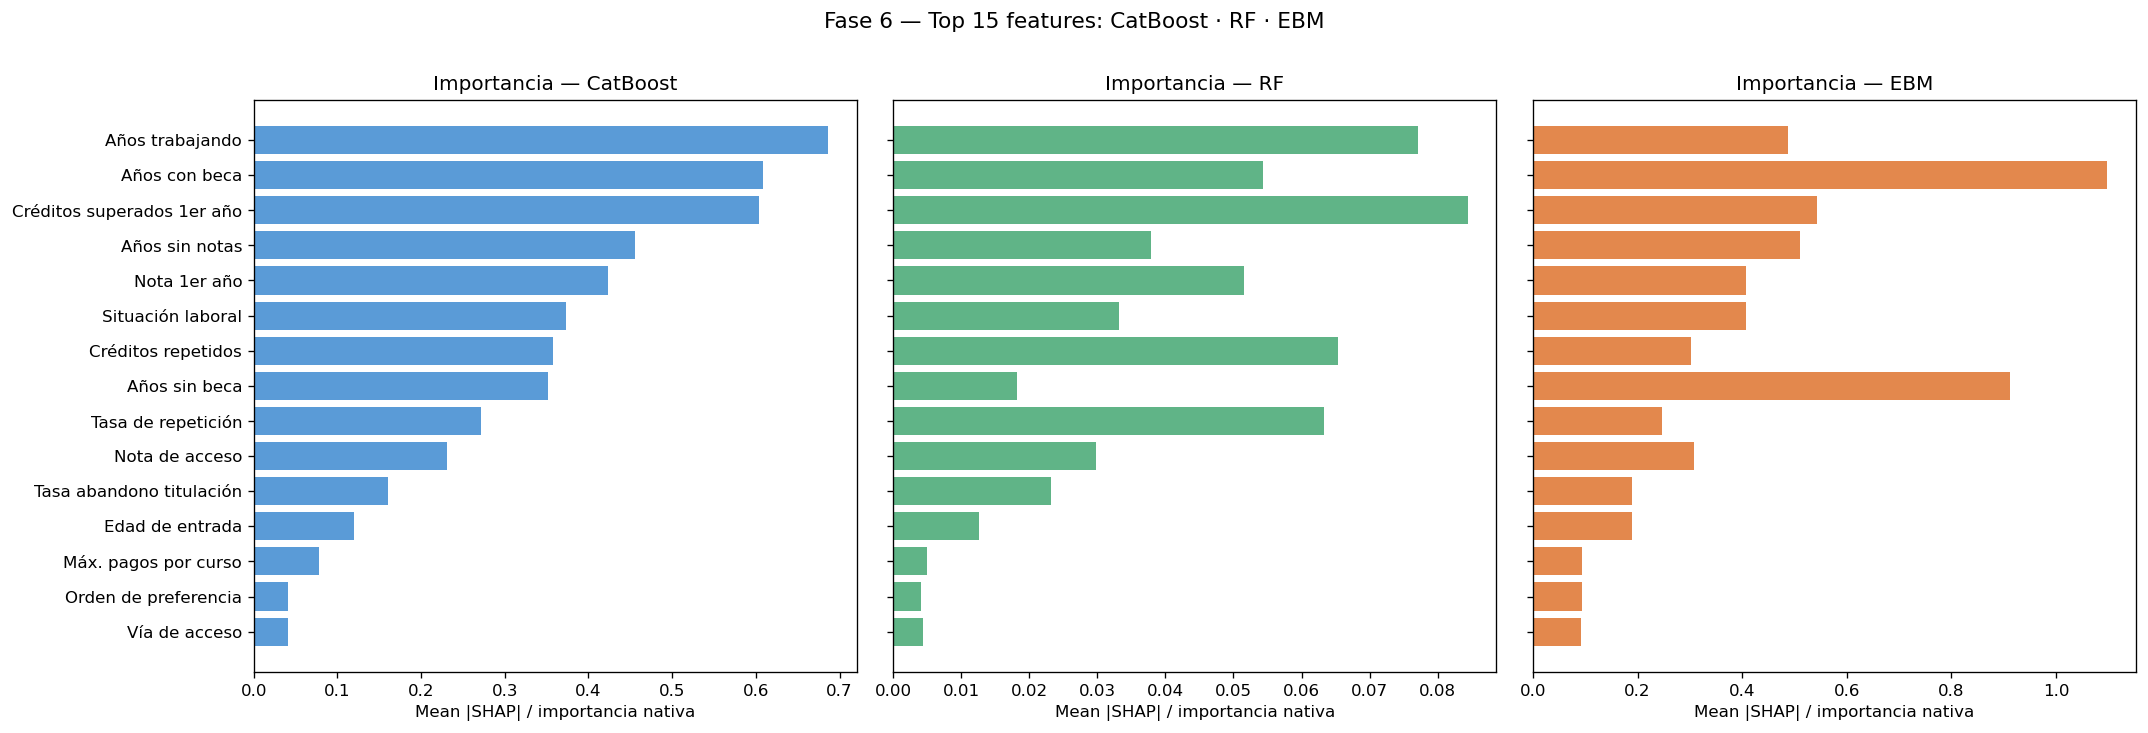

✅ Bar plot guardado.


In [11]:
# ============================================================
# CELDA 11: GRÁFICO 2 — BAR PLOT COMPARATIVO TRES MODELOS
# ============================================================
top_n        = 15
features_top = df_imp.nsmallest(top_n, 'rank_medio').index.tolist()

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
for ax, modelo, color in zip(axes, ['CatBoost','RF','EBM'], ['#3182ce','#38a169','#dd6b20']):
    vals = df_imp.loc[features_top, modelo].sort_values()
    # Usar nombres legibles en el eje Y
    labels = [nombre_legible(f) for f in vals.index]
    ax.barh(labels, vals.values, color=color, alpha=0.8)
    ax.set_title(f'Importancia — {modelo}', fontsize=12)
    ax.set_xlabel('Mean |SHAP| / importancia nativa')

plt.suptitle(f'Fase 6 — Top {top_n} features: CatBoost · RF · EBM', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(DIR_RESULTS / 'shap_bar_comparativo.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Bar plot guardado.')

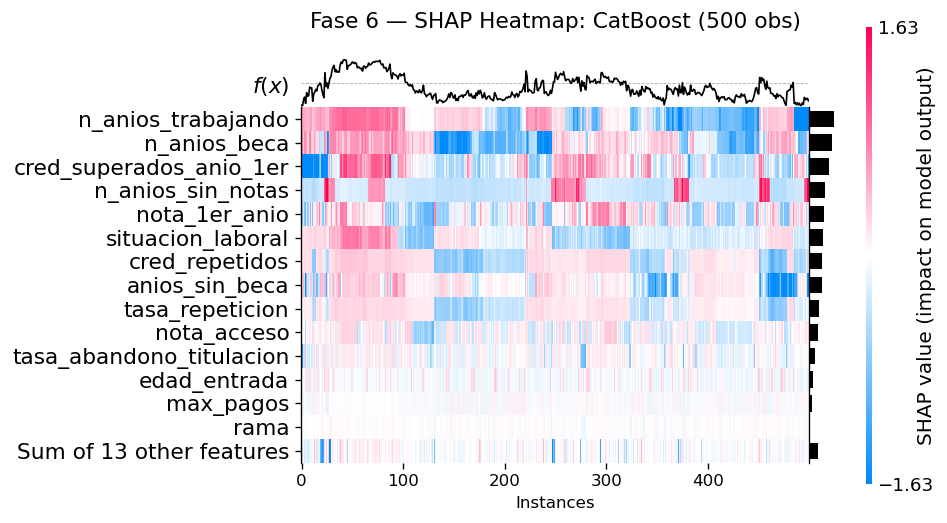

✅ Heatmap guardado.


In [12]:
# ============================================================
# CELDA 12: GRÁFICO 3 — HEATMAP SHAP (CATBOOST)
# SIEMPRE 500 obs — heatmap hace clustering O(n²).
# ============================================================
idx_muestra  = np.random.default_rng(42).choice(len(shap_cat), size=500, replace=False)
shap_muestra = shap_cat[idx_muestra]

fig, ax = plt.subplots(figsize=(10, 7))
shap.plots.heatmap(shap_muestra, max_display=15, show=False)
plt.title('Fase 6 — SHAP Heatmap: CatBoost (500 obs)', fontsize=13, pad=12)
plt.tight_layout()
plt.savefig(DIR_RESULTS / 'shap_heatmap_catboost.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Heatmap guardado.')

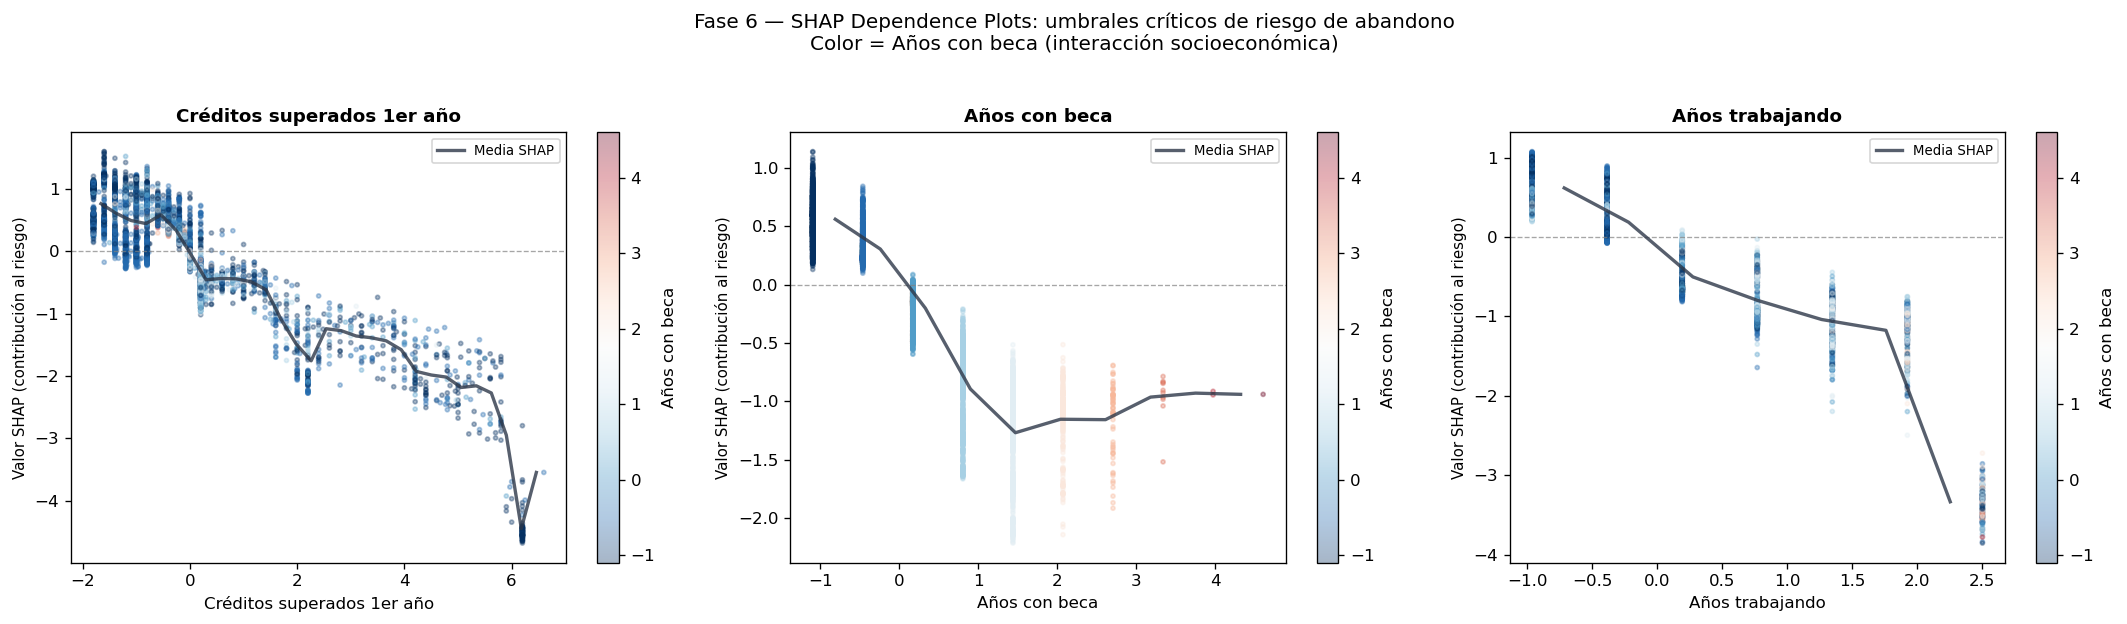

✅ Dependence plots guardados: shap_dependence_top3.png
Top 3 analizadas: ['Créditos superados 1er año', 'Años con beca', 'Años trabajando']


In [13]:
# ============================================================
# CELDA 13: GRÁFICO 4 — SHAP DEPENDENCE PLOTS (TOP 3) 🏆
# Para cada una de las 3 features con mayor consenso entre
# CatBoost, RF y EBM, muestra cómo varía el valor SHAP
# según el valor de la feature.
#
# Qué revelan:
#   - Umbrales críticos: el valor a partir del cual el riesgo
#     de abandono se dispara bruscamente
#   - Interacción: el color muestra si el efecto cambia
#     dependiendo del valor de la 2ª feature más importante
#   - Linealidad o no linealidad del efecto
#
# Color = n_anios_beca (proxy de situación socioeconómica)
# ============================================================
top3_features = df_imp.nsmallest(3, 'rank_medio').index.tolist()

# Extraer matriz SHAP CatBoost como array numpy
shap_vals_arr = shap_cat.values
if shap_vals_arr.ndim == 3:
    shap_vals_arr = shap_vals_arr[:, :, 1]

# Feature de color: n_anios_beca si existe, si no la 4ª más importante
color_feat = 'n_anios_beca' if 'n_anios_beca' in feature_names else top3_features[0]
color_idx  = feature_names.index(color_feat)
color_vals = X_test.iloc[:, color_idx].values

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, feat in zip(axes, top3_features):
    feat_idx   = feature_names.index(feat)
    feat_vals  = X_test.iloc[:, feat_idx].values
    shap_vals_f = shap_vals_arr[:, feat_idx]

    sc = ax.scatter(
        feat_vals, shap_vals_f,
        c=color_vals, cmap='RdBu_r',
        alpha=0.35, s=6, rasterized=True
    )
    ax.axhline(0, color='gray', linewidth=0.8, linestyle='--', alpha=0.7)

    # Línea de tendencia suavizada
    from scipy.stats import binned_statistic
    bins = min(30, len(np.unique(feat_vals)))
    if bins > 3:
        stat, edges, _ = binned_statistic(feat_vals, shap_vals_f, statistic='mean', bins=bins)
        centros = (edges[:-1] + edges[1:]) / 2
        mask_valid = ~np.isnan(stat)
        ax.plot(centros[mask_valid], stat[mask_valid],
                color='#2d3748', linewidth=2, alpha=0.8, label='Media SHAP')

    ax.set_xlabel(nombre_legible(feat), fontsize=10)
    ax.set_ylabel('Valor SHAP (contribución al riesgo)', fontsize=9)
    ax.set_title(nombre_legible(feat), fontsize=11, fontweight='bold')
    plt.colorbar(sc, ax=ax, label=nombre_legible(color_feat))
    ax.legend(fontsize=8)

plt.suptitle(
    'Fase 6 — SHAP Dependence Plots: umbrales críticos de riesgo de abandono\n'
    'Color = ' + nombre_legible(color_feat) + ' (interacción socioeconómica)',
    fontsize=12, y=1.03
)
plt.tight_layout()
ruta_dep = DIR_RESULTS / 'shap_dependence_top3.png'
plt.savefig(ruta_dep, dpi=120, bbox_inches='tight')
plt.show()
print(f'✅ Dependence plots guardados: {ruta_dep.name}')
print(f'Top 3 analizadas: {[nombre_legible(f) for f in top3_features]}')

In [14]:
# ============================================================
# CELDA 14: ANÁLISIS CONSENSO Y DISCREPANCIAS
# ============================================================
print('Top 5 MAYOR CONSENSO (tres modelos de acuerdo):')
print(df_imp.nsmallest(5, 'discrepancia')[['rank_cat','rank_rf','rank_ebm','discrepancia']].to_string())
print('\nTop 5 MAYOR DISCREPANCIA (modelos en desacuerdo):')
print(df_imp.nlargest(5, 'discrepancia')[['rank_cat','rank_rf','rank_ebm','discrepancia']].to_string())

Top 5 MAYOR CONSENSO (tres modelos de acuerdo):
                          rank_cat  rank_rf  rank_ebm  discrepancia
edad_entrada                    12       12        12             0
nota_1er_anio                    5        6         6             1
tasa_abandono_titulacion        11       10        11             1
via_acceso                      16       16        15             1
cred_superados_anio_1er          3        1         3             2

Top 5 MAYOR DISCREPANCIA (modelos en desacuerdo):
                       rank_cat  rank_rf  rank_ebm  discrepancia
nota_1er_anio_missing        27       13        18            14
anios_sin_beca                8       11         2             9
nota_selectividad            21       14        19             7
rama                         14       21        20             7
cred_repetidos                7        3         9             6


In [15]:
# ============================================================
# CELDA 15: GENERAR HTML
# Incluye los 4 gráficos: beeswarm, bar, heatmap y dependence.
# Nombres legibles desde NOMBRES_LEGIBLES_FEATURES.
# render_pagina_desde_fichero — estándar del proyecto.
# ============================================================
def img_b64(ruta: Path) -> str:
    if not ruta.exists():
        return ''
    with open(ruta, 'rb') as f:
        return base64.b64encode(f.read()).decode()

def bloque_imagen(b64: str, titulo: str, caption: str) -> str:
    if not b64:
        return f'<p style="color:#e53e3e">⚠️ No disponible: {titulo}</p>'
    return (
        '<div style="margin:24px 0">'
        f'<h3 style="color:#2d3748;font-size:15px">{titulo}</h3>'
        f'<img src="data:image/png;base64,{b64}" '
        'style="max-width:100%;border-radius:6px;box-shadow:0 2px 8px rgba(0,0,0,.1)">'
        f'<p style="color:#718096;font-size:12px;margin-top:6px">{caption}</p>'
        '</div>'
    )

# Tabla top 10 con nombres legibles
top10 = df_imp.nsmallest(10, 'rank_medio').reset_index()
filas_tabla = ''
for _, row in top10.iterrows():
    nombre = nombre_legible(row['index'])
    filas_tabla += (
        '<tr>'
        f'<td style="padding:7px 12px;font-weight:600">{nombre}</td>'
        f'<td style="padding:7px 12px;font-size:11px;color:#718096">{row["index"]}</td>'
        f'<td style="padding:7px 12px;text-align:right">{row["CatBoost"]:.4f}</td>'
        f'<td style="padding:7px 12px;text-align:right">{int(row["rank_cat"])}</td>'
        f'<td style="padding:7px 12px;text-align:right">{row["RF"]:.4f}</td>'
        f'<td style="padding:7px 12px;text-align:right">{int(row["rank_rf"])}</td>'
        f'<td style="padding:7px 12px;text-align:right">{row["EBM"]:.4f}</td>'
        f'<td style="padding:7px 12px;text-align:right">{int(row["rank_ebm"])}</td>'
        f'<td style="padding:7px 12px;text-align:right">{row["rank_medio"]:.1f}</td>'
        '</tr>'
    )

contenido = (
    '<h2 style="color:#2d3748">Fase 6 — SHAP Global: Importancia de Features</h2>'
    '<p style="color:#4a5568;font-size:14px;max-width:800px">'
    'Análisis de importancia global con SHAP sobre el conjunto de test '
    '(6.725 observaciones, 27 features). '
    'CatBoost y RF mediante TreeExplainer; EBM mediante su método nativo. '
    'Incluye <strong>dependence plots</strong> que revelan umbrales críticos de riesgo.'
    '</p>'
    + bloque_imagen(
        img_b64(DIR_RESULTS / 'shap_bootstrap_ic.png'),
        '🏆 Bootstrap Confidence Intervals — Importancias SHAP',
        'IC 95% calculado con 200 remuestras bootstrap de 500 observaciones. '
        'Barras de error estrechas = importancia robusta y estable. '
        'Barras anchas = importancia sensible a la muestra, interpretar con cautela.')
+ bloque_imagen(
        img_b64(DIR_RESULTS / 'shap_beeswarm_catboost.png'),
        'Beeswarm plot — CatBoost',
        'Cada punto = observación. Eje X = valor SHAP. '
        'Color = valor de la feature (rojo=alto, azul=bajo).')
    + bloque_imagen(
        img_b64(DIR_RESULTS / 'shap_bar_comparativo.png'),
        'Bar plot comparativo — CatBoost · RF · EBM',
        'Importancia media por feature en los tres modelos. '
        'Consenso = top en los tres. Nombres legibles en el eje.')
    + bloque_imagen(
        img_b64(DIR_RESULTS / 'shap_heatmap_catboost.png'),
        'Heatmap SHAP — CatBoost (muestra 500 obs)',
        'Mapa de calor de valores SHAP. Patrones de comportamiento del modelo.')
    + bloque_imagen(
        img_b64(DIR_RESULTS / 'shap_dependence_top3.png'),
        '🏆 SHAP Dependence Plots — Umbrales críticos de riesgo (Top 3 features)',
        'Cada punto = alumno. Eje X = valor de la feature, eje Y = contribución SHAP al riesgo. '
        'La línea negra es la tendencia media. Revela el umbral exacto a partir del cual '
        'cada variable empieza a aumentar el riesgo de abandono. '
        'Color = años con beca (interacción socioeconómica): rojo = más años con beca.')
    + '<h3 style="color:#2d3748;margin-top:28px">Top 10 features — consenso tres modelos</h3>'
    + '<table style="width:100%;border-collapse:collapse;font-size:13px">'
    + '<thead><tr style="background:#edf2f7">'
    + '<th style="padding:7px 12px;text-align:left">Feature</th>'
    + '<th style="padding:7px 12px;text-align:left;font-size:11px;color:#718096">Código</th>'
    + '<th style="padding:7px 12px;text-align:right">SHAP Cat</th>'
    + '<th style="padding:7px 12px;text-align:right">Rank Cat</th>'
    + '<th style="padding:7px 12px;text-align:right">SHAP RF</th>'
    + '<th style="padding:7px 12px;text-align:right">Rank RF</th>'
    + '<th style="padding:7px 12px;text-align:right">Imp EBM</th>'
    + '<th style="padding:7px 12px;text-align:right">Rank EBM</th>'
    + '<th style="padding:7px 12px;text-align:right">Rank medio</th>'
    + '</tr></thead>'
    + f'<tbody>{filas_tabla}</tbody></table>'
    + '<div style="margin-top:24px;padding:16px;background:#ebf8ff;'
    'border-left:4px solid #3182ce;border-radius:6px;font-size:13px;color:#2c5282">'
    '<strong>Interpretación:</strong> Menor rango medio = mayor consenso entre modelos. '
    'Los dependence plots muestran que el efecto de cada feature no es lineal — '
    'existe un umbral crítico a partir del cual el riesgo se dispara, '
    'información clave para diseñar intervenciones preventivas concretas.'
    '</div>'
)

html_completo = render_pagina_desde_fichero('f6_m01a_shap_global.ipynb', contenido)
(DIR_HTML / 'm01a_shap_global.html').write_text(html_completo, encoding='utf-8')
print(f'✅ HTML generado: {DIR_HTML / "m01a_shap_global.html"}')

✅ HTML generado: C:\Users\mjmor\OneDrive - Universitat Jaume I\2.- AU_UJI\docs\html\fase6\m01a_shap_global.html
